# Procrustes Analysis and PCA

[*] 系統共抓取到 19 組檔案，準備處理...

[*] 處理完畢！從 19 張圖片中，成功提取了 19 個花瓣輪廓。
[*] GPA 在第 4 次迭代收斂。


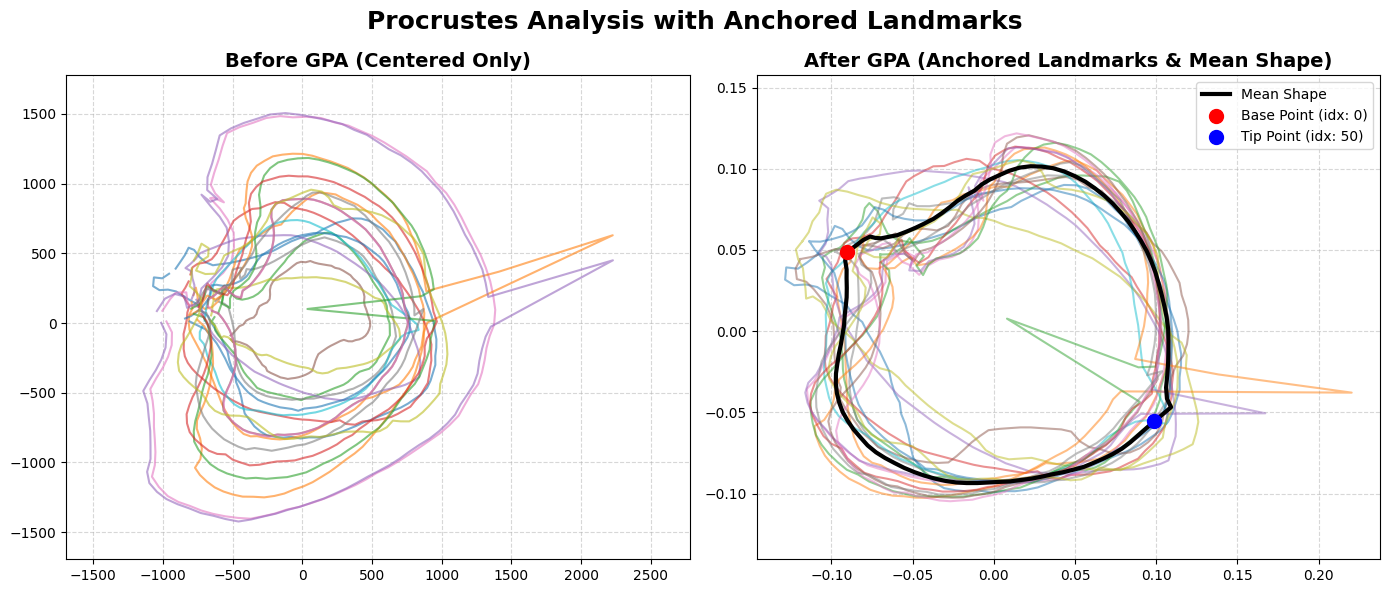


[*] 開始進行主成分分析 (PCA)...


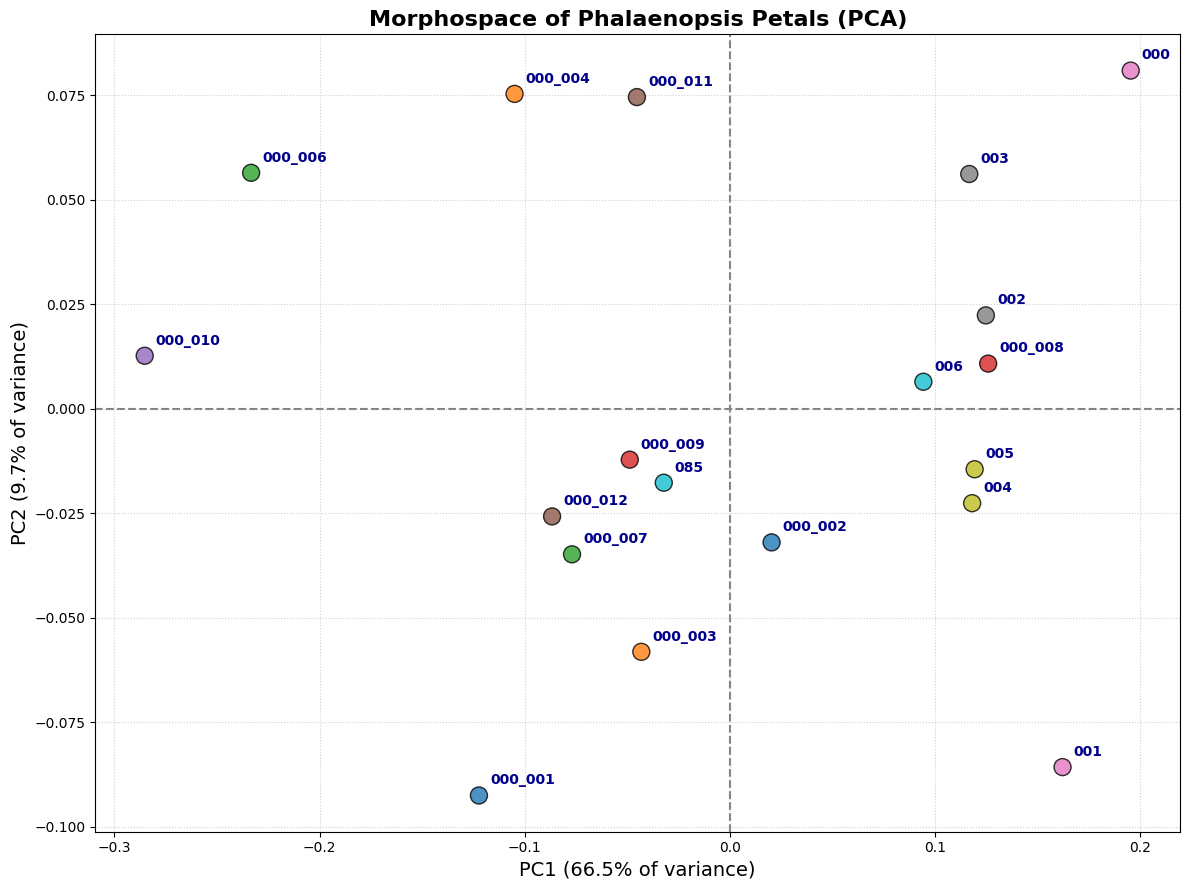

[*] PCA 完成！PC1 解釋了 66.5% 的變異，PC2 解釋了 9.7%。


In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
import os
import glob

# ==========================================
# 1. 定義 GPA 函數 (維持不變)
# ==========================================
def perform_gpa(shapes, max_iter=10, tol=1e-5):
    N, num_points, dims = shapes.shape
    centers = np.mean(shapes, axis=1, keepdims=True)
    centered_shapes = shapes - centers
    centroid_sizes = np.linalg.norm(centered_shapes, axis=(1, 2), keepdims=True)
    scaled_shapes = centered_shapes / centroid_sizes
    
    aligned_shapes = np.copy(scaled_shapes)
    mean_shape = aligned_shapes[0] 
    
    for iteration in range(max_iter):
        for i in range(N):
            R, _ = orthogonal_procrustes(aligned_shapes[i], mean_shape)
            aligned_shapes[i] = np.dot(aligned_shapes[i], R)
            
        new_mean_shape = np.mean(aligned_shapes, axis=0)
        new_mean_shape /= np.linalg.norm(new_mean_shape)
        
        diff = np.linalg.norm(new_mean_shape - mean_shape)
        mean_shape = new_mean_shape
        if diff < tol:
            print(f"[*] GPA 在第 {iteration+1} 次迭代收斂。")
            break
    return aligned_shapes, mean_shape

# ==========================================
# 2. 設定資料夾路徑與參數
# ==========================================
image_dir = './raw_images_0302_labeled_7/the7images/'
mask_dir = './raw_images_0302_labeled_7/the7masks/'

target_class_id = 7 
base_class_id = 1   
num_landmarks = 200
# 🌟 已移除 exclude_ratio，改用雙錨點 (Base & Tip) 策略

all_petals_landmarks = []
valid_filenames = []

# ==========================================
# 3. 批次處理影像 (🌟 錨定半特徵點策略 🌟)
# ==========================================
image_paths = sorted(glob.glob(os.path.join(image_dir, '*_image.png')))

if not image_paths:
    print(f"[警告] 在 {image_dir} 中找不到任何影像。")
else:
    print(f"[*] 系統共抓取到 {len(image_paths)} 組檔案，準備處理...")

for img_path in image_paths:
    filename = os.path.basename(img_path)
    mask_filename = filename.replace('_image.png', '_mask.png')
    mask_path = os.path.join(mask_dir, mask_filename)
    display_name = filename.replace('_image.png', '') 
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"    - [跳過] 找不到對應的 Mask: {mask_filename}")
        continue

    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    cnts_c1, _ = cv2.findContours(mask_c1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c1_points = np.vstack(cnts_c1) if cnts_c1 else None

    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    mask_c7 = cv2.morphologyEx(mask_c7, cv2.MORPH_OPEN, kernel)
    cnts_c7, _ = cv2.findContours(mask_c7, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    petal_counter = 1 
    
    for cnt in cnts_c7:
        if cv2.contourArea(cnt) < 100: continue
        N_pts = len(cnt)
        if N_pts < 20: continue 

        # --- 步驟 A: 尋找基部(最近點)與尖端(最遠點) ---
        min_dist = float('inf')
        max_dist = 0
        base_idx = 0
        tip_idx = 0

        if c1_points is not None:
            for idx, pt in enumerate(cnt):
                diff = c1_points[:, 0, :] - pt[0]
                sq_dists = np.sum(diff**2, axis=1)
                local_min = np.min(sq_dists)
                
                if local_min < min_dist:
                    min_dist = local_min
                    base_idx = idx
                if local_min > max_dist:
                    max_dist = local_min
                    tip_idx = idx

        if base_idx == tip_idx:
            continue # 無法區分頭尾，跳過此輪廓

        # --- 步驟 B: 依照輪廓順序，將花瓣切分為左右兩半 ---
        if base_idx < tip_idx:
            path1 = cnt[base_idx : tip_idx + 1]
            path2 = np.concatenate((cnt[tip_idx : ], cnt[ : base_idx + 1]))
        else:
            path1 = np.concatenate((cnt[base_idx : ], cnt[ : tip_idx + 1]))
            path2 = cnt[tip_idx : base_idx + 1]

        if len(path1) < 4 or len(path2) < 4:
            continue # 某一半點數太少，無法進行內插

        x1, y1 = path1[:, 0, 0], path1[:, 0, 1]
        x2, y2 = path2[:, 0, 0], path2[:, 0, 1]
        
        # --- 步驟 C: 雙側等距內插與縫合 ---
        try:
            # 兩半各自內插取 51 個點 (起點與終點皆包含)
            tck1, _ = interp.splprep([x1, y1], s=3.0, per=False) 
            new_x1, new_y1 = interp.splev(np.linspace(0, 1, 51), tck1)
            
            tck2, _ = interp.splprep([x2, y2], s=3.0, per=False) 
            new_x2, new_y2 = interp.splev(np.linspace(0, 1, 51), tck2)
            
            # 縫合：去掉各自的最後一個點 (避免重複)，形成完美的 100 點封閉輪廓
            # 此時：index 0 是基部 (Base)，index 50 是尖端 (Tip)
            final_x = np.concatenate((new_x1[:-1], new_x2[:-1]))
            final_y = np.concatenate((new_y1[:-1], new_y2[:-1]))
            
            landmark_coords = np.column_stack((final_x, final_y))
            all_petals_landmarks.append(landmark_coords)
            
            final_label = f"{display_name}_p{petal_counter}" if len(cnts_c7) > 1 else display_name
            valid_filenames.append(final_label)
            petal_counter += 1
            
        except Exception as e:
            print(f"    - [跳過] {filename} 輪廓內插失敗: {e}")

# ==========================================
# 4. 執行 GPA 與 視覺化
# ==========================================
shapes_array = np.array(all_petals_landmarks)
print(f"\n[*] 處理完畢！從 {len(image_paths)} 張圖片中，成功提取了 {len(shapes_array)} 個花瓣輪廓。")

if len(shapes_array) < 2:
    print("提取出的形狀數量不足 2 個，無法進行 GPA 分析。請檢查影像。")
else:
    aligned_shapes, mean_shape = perform_gpa(shapes_array)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].set_title("Before GPA (Centered Only)", fontsize=14, fontweight='bold')
    for i in range(len(shapes_array)):
        center = np.mean(shapes_array[i], axis=0)
        centered = shapes_array[i] - center
        axes[0].plot(centered[:, 0], centered[:, 1], alpha=0.6, linewidth=1.5)
    axes[0].axis('equal')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].set_title("After GPA (Anchored Landmarks & Mean Shape)", fontsize=14, fontweight='bold')
    for i in range(len(aligned_shapes)):
        # 將輪廓閉合繪製 (把第一個點連回最後一個點)
        closed_x = np.append(aligned_shapes[i, :, 0], aligned_shapes[i, 0, 0])
        closed_y = np.append(aligned_shapes[i, :, 1], aligned_shapes[i, 0, 1])
        axes[1].plot(closed_x, closed_y, alpha=0.5, linewidth=1.5)
    
    # 畫出黑色的平均形狀
    mean_closed_x = np.append(mean_shape[:, 0], mean_shape[0, 0])
    mean_closed_y = np.append(mean_shape[:, 1], mean_shape[0, 1])
    axes[1].plot(mean_closed_x, mean_closed_y, color='black', linewidth=3, label='Mean Shape')
    
    # 🌟 精準標示錨點：第 0 點為基部，第 50 點為尖端 🌟
    axes[1].scatter(mean_shape[0, 0], mean_shape[0, 1], color='red', s=100, label='Base Point (idx: 0)', zorder=5)
    axes[1].scatter(mean_shape[50, 0], mean_shape[50, 1], color='blue', s=100, label='Tip Point (idx: 50)', zorder=5)

    axes[1].axis('equal')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend()

    plt.suptitle("Procrustes Analysis with Anchored Landmarks", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. 執行主成分分析 (PCA) 與繪製形態空間
# ==========================================
    print("\n[*] 開始進行主成分分析 (PCA)...")
    N, num_points, dims = aligned_shapes.shape
    flattened_shapes = aligned_shapes.reshape(N, -1)

    pca = PCA(n_components=2)
    pcs = pca.fit_transform(flattened_shapes)
    explained_variance = pca.explained_variance_ratio_ * 100

    fig_pca, ax_pca = plt.subplots(figsize=(12, 9)) 
    scatter = ax_pca.scatter(pcs[:, 0], pcs[:, 1], c=range(N), cmap='tab10', s=150, alpha=0.8, edgecolors='k', zorder=3)

    for i in range(N):
        actual_name = valid_filenames[i]
        ax_pca.annotate(actual_name, (pcs[i, 0], pcs[i, 1]),
                    xytext=(8, 8), textcoords='offset points', 
                    fontsize=10, fontweight='bold', color='darkblue')

    ax_pca.set_title("Morphospace of Phalaenopsis Petals (PCA)", fontsize=16, fontweight='bold')
    ax_pca.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% of variance)", fontsize=14)
    ax_pca.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% of variance)", fontsize=14)

    ax_pca.axhline(0, color='gray', linestyle='--', linewidth=1.5, zorder=1)
    ax_pca.axvline(0, color='gray', linestyle='--', linewidth=1.5, zorder=1)
    ax_pca.grid(True, linestyle=':', alpha=0.6, zorder=0)

    plt.tight_layout()
    plt.show()
    
    print(f"[*] PCA 完成！PC1 解釋了 {explained_variance[0]:.1f}% 的變異，PC2 解釋了 {explained_variance[1]:.1f}%。")

# sliding semilandmark

[*] 系統共抓取到 19 組檔案，準備處理...

[*] 處理完畢！成功提取了 19 個花瓣輪廓。


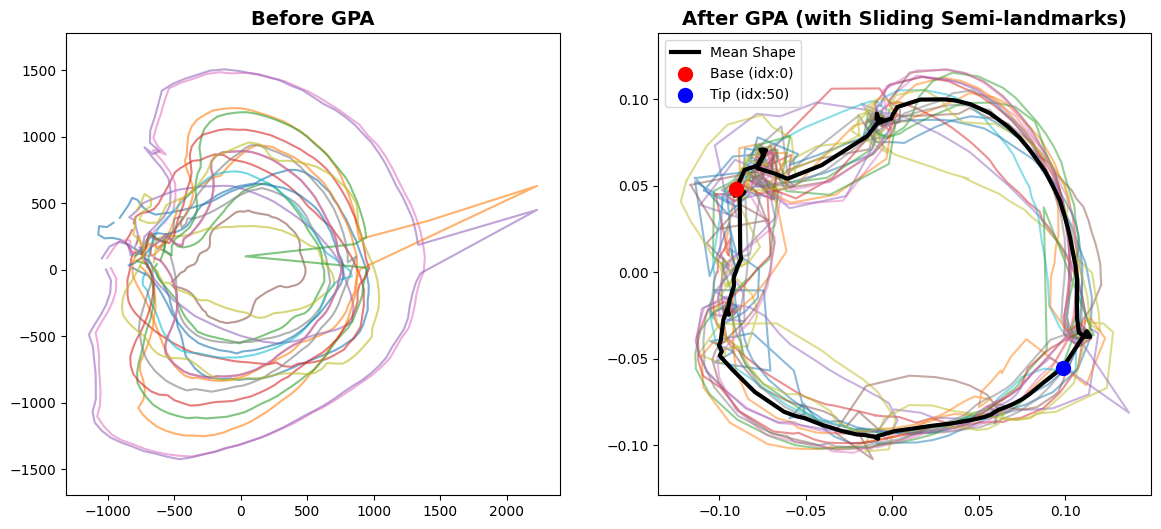


[*] 開始進行主成分分析 (PCA)...


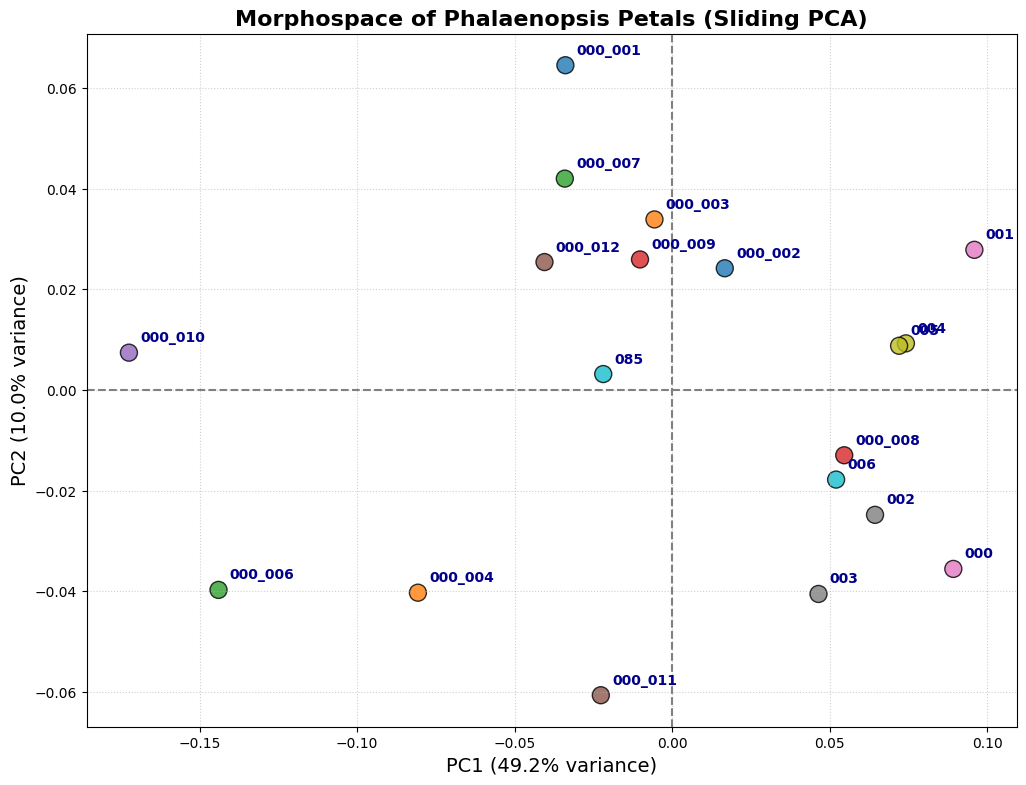

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
import os
import glob

# ==========================================
# 1. 定義滑動半特徵點與 GPA 函數 🌟 (重大升級) 🌟
# ==========================================
def slide_points(shape, mean_shape, anchors=[0, 50], step_size=0.5):
    """
    計算切線並讓半特徵點沿著輪廓邊緣滑動，以最小化 Procrustes 距離
    """
    new_shape = np.copy(shape)
    N = len(shape)
    for i in range(N):
        if i in anchors:
            continue # 錨點 (基部與尖端) 絕對不准滑動！
            
        # 計算該點的局部切線向量 (利用前後兩個點)
        prev_idx = (i - 1) % N
        next_idx = (i + 1) % N
        tangent = shape[next_idx] - shape[prev_idx]
        norm = np.linalg.norm(tangent)
        
        if norm > 1e-6:
            tangent = tangent / norm # 單位切線向量
        else:
            continue
            
        # 計算該點到平均形狀目標點的向量
        vec_to_mean = mean_shape[i] - shape[i]
        
        # 將距離向量投影到切線上 (算出需要滑動的距離)
        slide_dist = np.dot(vec_to_mean, tangent)
        
        # 更新點的位置 (加入 step_size 避免滑動過頭導致點擠在一起)
        new_shape[i] = shape[i] + (step_size * slide_dist) * tangent
        
    return new_shape

def perform_gpa_with_sliding(shapes, max_iter=20, tol=1e-5):
    N, num_points, dims = shapes.shape
    
    # 初始縮放與置中
    centers = np.mean(shapes, axis=1, keepdims=True)
    centered_shapes = shapes - centers
    centroid_sizes = np.linalg.norm(centered_shapes, axis=(1, 2), keepdims=True)
    scaled_shapes = centered_shapes / centroid_sizes
    
    aligned_shapes = np.copy(scaled_shapes)
    mean_shape = aligned_shapes[0] 
    
    for iteration in range(max_iter):
        # 步驟 1: 旋轉對齊 (Procrustes)
        for i in range(N):
            R, _ = orthogonal_procrustes(aligned_shapes[i], mean_shape)
            aligned_shapes[i] = np.dot(aligned_shapes[i], R)
            
        # 步驟 2: 執行半特徵點滑動 (Sliding) 🌟
        if iteration > 0: # 第一次先對齊大方向，第二次才開始滑動
            for i in range(N):
                aligned_shapes[i] = slide_points(aligned_shapes[i], mean_shape, anchors=[0, 50])
                
        # 步驟 3: 重新計算平均形狀
        new_mean_shape = np.mean(aligned_shapes, axis=0)
        new_mean_shape /= np.linalg.norm(new_mean_shape)
        
        diff = np.linalg.norm(new_mean_shape - mean_shape)
        mean_shape = new_mean_shape
        if diff < tol:
            print(f"[*] GPA+Sliding 在第 {iteration+1} 次迭代收斂。")
            break
            
    return aligned_shapes, mean_shape

# ==========================================
# 2. 設定資料夾路徑與參數
# ==========================================
image_dir = './raw_images_0302_labeled_7/the7images/'
mask_dir = './raw_images_0302_labeled_7/the7masks/'

target_class_id = 7 
base_class_id = 1   
num_landmarks = 100 

all_petals_landmarks = []
valid_filenames = []

# ==========================================
# 3. 批次處理影像 (錨定切分)
# ==========================================
image_paths = sorted(glob.glob(os.path.join(image_dir, '*_image.png')))
print(f"[*] 系統共抓取到 {len(image_paths)} 組檔案，準備處理...")

for img_path in image_paths:
    filename = os.path.basename(img_path)
    mask_filename = filename.replace('_image.png', '_mask.png')
    mask_path = os.path.join(mask_dir, mask_filename)
    display_name = filename.replace('_image.png', '') 
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: continue

    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    cnts_c1, _ = cv2.findContours(mask_c1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c1_points = np.vstack(cnts_c1) if cnts_c1 else None

    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    mask_c7 = cv2.morphologyEx(mask_c7, cv2.MORPH_OPEN, kernel)
    cnts_c7, _ = cv2.findContours(mask_c7, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    petal_counter = 1 
    for cnt in cnts_c7:
        if cv2.contourArea(cnt) < 100: continue
        N_pts = len(cnt)
        if N_pts < 20: continue 

        min_dist, max_dist = float('inf'), 0
        base_idx, tip_idx = 0, 0

        if c1_points is not None:
            for idx, pt in enumerate(cnt):
                diff = c1_points[:, 0, :] - pt[0]
                sq_dists = np.sum(diff**2, axis=1)
                local_min = np.min(sq_dists)
                if local_min < min_dist: min_dist, base_idx = local_min, idx
                if local_min > max_dist: max_dist, tip_idx = local_min, idx

        if base_idx == tip_idx: continue

        if base_idx < tip_idx:
            path1 = cnt[base_idx : tip_idx + 1]
            path2 = np.concatenate((cnt[tip_idx : ], cnt[ : base_idx + 1]))
        else:
            path1 = np.concatenate((cnt[base_idx : ], cnt[ : tip_idx + 1]))
            path2 = cnt[tip_idx : base_idx + 1]

        if len(path1) < 4 or len(path2) < 4: continue

        x1, y1 = path1[:, 0, 0], path1[:, 0, 1]
        x2, y2 = path2[:, 0, 0], path2[:, 0, 1]
        
        try:
            tck1, _ = interp.splprep([x1, y1], s=3.0, per=False) 
            new_x1, new_y1 = interp.splev(np.linspace(0, 1, 51), tck1)
            tck2, _ = interp.splprep([x2, y2], s=3.0, per=False) 
            new_x2, new_y2 = interp.splev(np.linspace(0, 1, 51), tck2)
            
            final_x = np.concatenate((new_x1[:-1], new_x2[:-1]))
            final_y = np.concatenate((new_y1[:-1], new_y2[:-1]))
            
            all_petals_landmarks.append(np.column_stack((final_x, final_y)))
            final_label = f"{display_name}_p{petal_counter}" if len(cnts_c7) > 1 else display_name
            valid_filenames.append(final_label)
            petal_counter += 1
        except Exception as e:
            continue

# ==========================================
# 4. 執行 GPA (含 Sliding) 與 視覺化
# ==========================================
shapes_array = np.array(all_petals_landmarks)
print(f"\n[*] 處理完畢！成功提取了 {len(shapes_array)} 個花瓣輪廓。")

if len(shapes_array) > 1:
    aligned_shapes, mean_shape = perform_gpa_with_sliding(shapes_array) # 🌟 呼叫新函數

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].set_title("Before GPA", fontsize=14, fontweight='bold')
    for i in range(len(shapes_array)):
        centered = shapes_array[i] - np.mean(shapes_array[i], axis=0)
        axes[0].plot(centered[:, 0], centered[:, 1], alpha=0.6, linewidth=1.5)
    axes[0].axis('equal')

    axes[1].set_title("After GPA (with Sliding Semi-landmarks)", fontsize=14, fontweight='bold')
    for i in range(len(aligned_shapes)):
        closed_x = np.append(aligned_shapes[i, :, 0], aligned_shapes[i, 0, 0])
        closed_y = np.append(aligned_shapes[i, :, 1], aligned_shapes[i, 0, 1])
        axes[1].plot(closed_x, closed_y, alpha=0.5, linewidth=1.5)
    
    mean_closed_x = np.append(mean_shape[:, 0], mean_shape[0, 0])
    mean_closed_y = np.append(mean_shape[:, 1], mean_shape[0, 1])
    axes[1].plot(mean_closed_x, mean_closed_y, color='black', linewidth=3, label='Mean Shape')
    axes[1].scatter(mean_shape[0, 0], mean_shape[0, 1], color='red', s=100, label='Base (idx:0)', zorder=5)
    axes[1].scatter(mean_shape[50, 0], mean_shape[50, 1], color='blue', s=100, label='Tip (idx:50)', zorder=5)

    axes[1].axis('equal')
    axes[1].legend()
    plt.show()

# ==========================================
# 5. 執行主成分分析 (PCA)
# ==========================================
    print("\n[*] 開始進行主成分分析 (PCA)...")
    N, num_points, dims = aligned_shapes.shape
    flattened_shapes = aligned_shapes.reshape(N, -1)

    pca = PCA(n_components=2)
    pcs = pca.fit_transform(flattened_shapes)
    explained_variance = pca.explained_variance_ratio_ * 100

    fig_pca, ax_pca = plt.subplots(figsize=(12, 9)) 
    scatter = ax_pca.scatter(pcs[:, 0], pcs[:, 1], c=range(N), cmap='tab10', s=150, alpha=0.8, edgecolors='k')

    for i in range(N):
        ax_pca.annotate(valid_filenames[i], (pcs[i, 0], pcs[i, 1]), xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold', color='darkblue')

    ax_pca.set_title("Morphospace of Phalaenopsis Petals (Sliding PCA)", fontsize=16, fontweight='bold')
    ax_pca.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)", fontsize=14)
    ax_pca.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)", fontsize=14)
    ax_pca.axhline(0, color='gray', linestyle='--')
    ax_pca.axvline(0, color='gray', linestyle='--')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Refactory


[*] 正在進行沿著主成分的漸進形狀重建與真實照片配對...


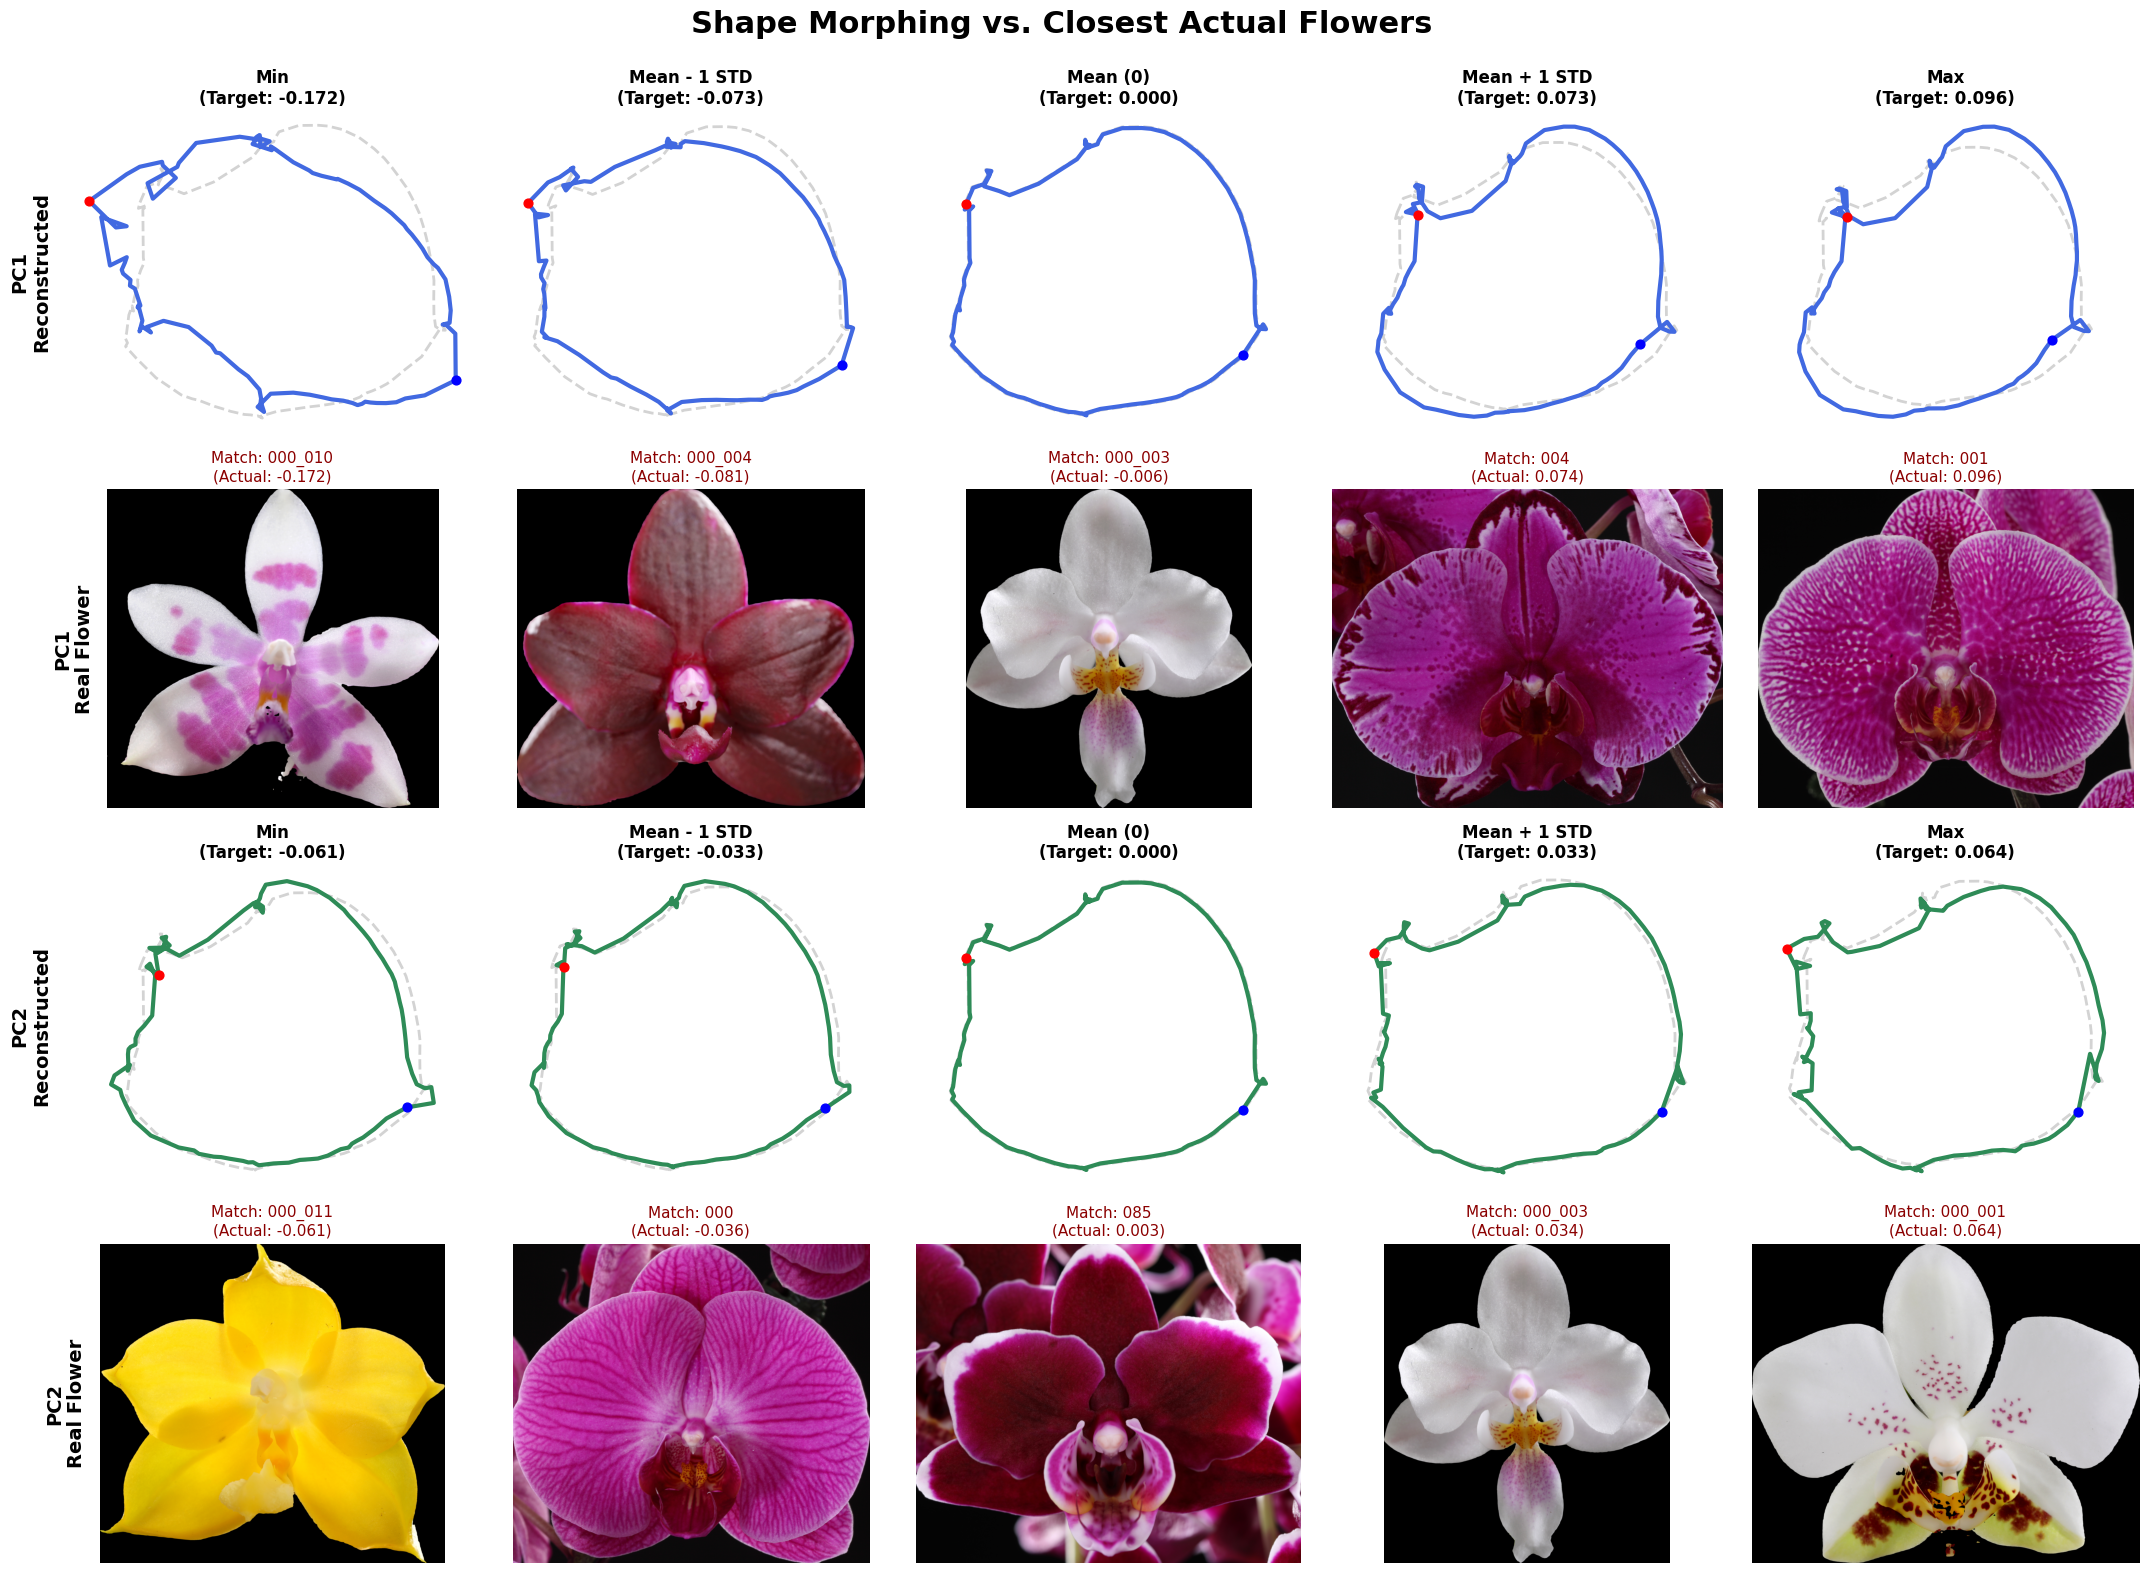

In [36]:
# ==========================================
# 6. 沿著主成分的漸進形狀重建與真實照片對比
# ==========================================
import os
import cv2

print("\n[*] 正在進行沿著主成分的漸進形狀重建與真實照片配對...")

# 1. 計算 PC1 與 PC2 的統計數值
pc1_scores = pcs[:, 0]
pc2_scores = pcs[:, 1]

pc1_std = np.std(pc1_scores)
pc2_std = np.std(pc2_scores)

pc1_targets = [np.min(pc1_scores), -pc1_std, 0, pc1_std, np.max(pc1_scores)]
pc2_targets = [np.min(pc2_scores), -pc2_std, 0, pc2_std, np.max(pc2_scores)]
labels = ["Min", "Mean - 1 STD", "Mean (0)", "Mean + 1 STD", "Max"]

# 2. 建立虛擬點進入 PCA 空間
syn_pc1 = np.zeros((5, 2))
syn_pc1[:, 0] = pc1_targets 
syn_pc2 = np.zeros((5, 2))
syn_pc2[:, 1] = pc2_targets 

# 3. 逆轉換回原始特徵空間
recon_pc1_shapes = pca.inverse_transform(syn_pc1).reshape(5, num_points, dims)
recon_pc2_shapes = pca.inverse_transform(syn_pc2).reshape(5, num_points, dims)

# 4. 輔助函式：尋找最接近目標分數的真實樣本 Index
def get_closest_sample_idx(scores_array, target_score):
    return np.argmin(np.abs(scores_array - target_score))

# 5. 繪製 4x5 網格圖 (加上真實照片)
fig_recon, axes_recon = plt.subplots(4, 5, figsize=(22, 16))
fig_recon.suptitle("Shape Morphing vs. Closest Actual Flowers", fontsize=22, fontweight='bold', y=0.98)

all_recon = np.vstack((recon_pc1_shapes, recon_pc2_shapes))
x_min, x_max = np.min(all_recon[:, :, 0]), np.max(all_recon[:, :, 0])
y_min, y_max = np.min(all_recon[:, :, 1]), np.max(all_recon[:, :, 1])
padding = 0.05

def plot_reconstructed_shape(ax, shape, color, title):
    """繪製單一重建形狀"""
    mean_closed_x = np.append(mean_shape[:, 0], mean_shape[0, 0])
    mean_closed_y = np.append(mean_shape[:, 1], mean_shape[0, 1])
    ax.plot(mean_closed_x, mean_closed_y, color='lightgray', linestyle='--', linewidth=2, zorder=1)
    
    closed_x = np.append(shape[:, 0], shape[0, 0])
    closed_y = np.append(shape[:, 1], shape[0, 1])
    ax.plot(closed_x, closed_y, color=color, linewidth=3, zorder=2)
    
    ax.scatter(shape[0, 0], shape[0, 1], color='red', s=40, zorder=3)
    ax.scatter(shape[50, 0], shape[50, 1], color='blue', s=40, zorder=3)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.set_ylim(y_min - padding, y_max + padding)
    ax.axis('equal')
    ax.axis('off')

def plot_closest_image(ax, actual_idx, target_score, is_pc1=True):
    """讀取並繪製最接近的原圖"""
    actual_label = valid_filenames[actual_idx]
    actual_score = pc1_scores[actual_idx] if is_pc1 else pc2_scores[actual_idx]
    
    # 透過檔名標籤找回原圖路徑
    base_name = actual_label.split('_p')[0]
    img_path = os.path.join(image_dir, f"{base_name}_image.png")
    
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, "Image Not Found", ha='center', va='center')
        
    ax.set_title(f"Match: {actual_label}\n(Actual: {actual_score:.3f})", fontsize=11, color='darkred')
    ax.axis('off')

# --- 繪製 PC1 區塊 (Row 0: 虛擬重建, Row 1: 真實照片) ---
for i in range(5):
    # 畫重建形狀
    title = f"{labels[i]}\n(Target: {pc1_targets[i]:.3f})"
    plot_reconstructed_shape(axes_recon[0, i], recon_pc1_shapes[i], 'royalblue', title)
    
    # 找最接近的照片並畫出
    closest_idx = get_closest_sample_idx(pc1_scores, pc1_targets[i])
    plot_closest_image(axes_recon[1, i], closest_idx, pc1_targets[i], is_pc1=True)

# 加上列標籤
axes_recon[0, 0].text(-0.1, 0.5, "PC1\nReconstructed", transform=axes_recon[0, 0].transAxes, fontsize=14, fontweight='bold', rotation=90, va='center', ha='center')
axes_recon[1, 0].text(-0.1, 0.5, "PC1\nReal Flower", transform=axes_recon[1, 0].transAxes, fontsize=14, fontweight='bold', rotation=90, va='center', ha='center')

# --- 繪製 PC2 區塊 (Row 2: 虛擬重建, Row 3: 真實照片) ---
for i in range(5):
    title = f"{labels[i]}\n(Target: {pc2_targets[i]:.3f})"
    plot_reconstructed_shape(axes_recon[2, i], recon_pc2_shapes[i], 'seagreen', title)
    
    closest_idx = get_closest_sample_idx(pc2_scores, pc2_targets[i])
    plot_closest_image(axes_recon[3, i], closest_idx, pc2_targets[i], is_pc1=False)

# 加上列標籤
axes_recon[2, 0].text(-0.1, 0.5, "PC2\nReconstructed", transform=axes_recon[2, 0].transAxes, fontsize=14, fontweight='bold', rotation=90, va='center', ha='center')
axes_recon[3, 0].text(-0.1, 0.5, "PC2\nReal Flower", transform=axes_recon[3, 0].transAxes, fontsize=14, fontweight='bold', rotation=90, va='center', ha='center')

plt.tight_layout(rect=[0.02, 0, 1, 0.98]) # 預留左側標籤空間
plt.show()

# 主成分佔比分析

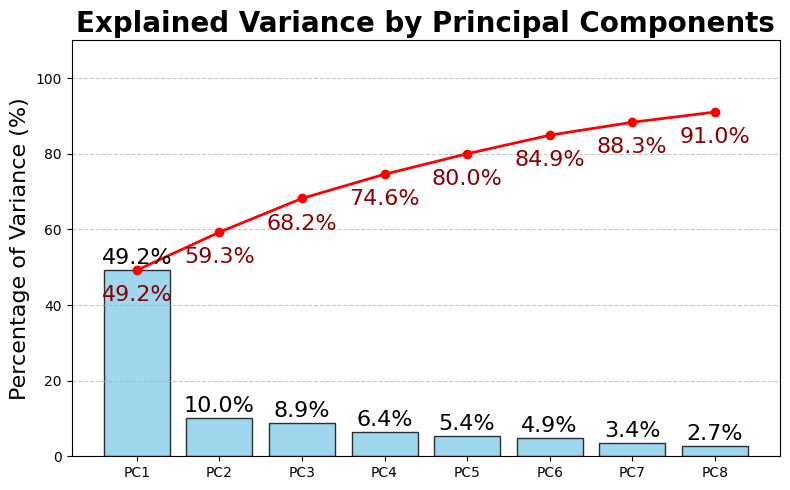

In [37]:
# ==========================================
# 繪製主成分解釋變異佔比直方圖 (Scree Plot)
# ==========================================
max_components = min(8, N - 1)
pca_multi = PCA(n_components=max_components)
pca_multi.fit(flattened_shapes)

explained_var = pca_multi.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)
x_labels = [f"PC{i+1}" for i in range(max_components)]

fig_var, ax_var = plt.subplots(figsize=(8, 5))
bars = ax_var.bar(x_labels, explained_var, color='skyblue', edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    ax_var.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontsize=16)
    
ax_var.plot(x_labels, cumulative_var, color='red', marker='o', linewidth=2)
for i, val in enumerate(cumulative_var):
    ax_var.text(i, val - 4, f"{val:.1f}%", ha='center', va='top', color='darkred', fontsize=16)
    
ax_var.set_title("Explained Variance by Principal Components", fontsize=20, fontweight='bold')
ax_var.set_ylabel("Percentage of Variance (%)", fontsize=16)
ax_var.set_ylim(0, 110)
ax_var.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 計算傳統幾何特徵 (長寬比) 並存入表格

In [38]:
import pandas as pd
import math

# ==========================================
# 定義生物學中軸與寬度分析函式
# ==========================================
def get_aspect_ratio(binary_mask, origin_point):
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: return None
    cnt = max(contours, key=cv2.contourArea)
    
    max_dist, min_dist = 0, float('inf')
    farthest_point, closest_point = None, None
    
    for pt in cnt:
        p = pt[0]
        dist = np.linalg.norm(p - origin_point)
        if dist > max_dist: max_dist, farthest_point = dist, tuple(p)
        if dist < min_dist: min_dist, closest_point = dist, tuple(p)
            
    base_np = np.array(closest_point, dtype=float)
    tip_np = np.array(farthest_point, dtype=float)
    axis_vector = tip_np - base_np
    true_length = np.linalg.norm(axis_vector)
    
    true_width, aspect_ratio = 0, 0
    if true_length > 0:
        unit_axis = axis_vector / true_length
        perp_vector = np.array([-unit_axis[1], unit_axis[0]])
        
        max_pos_proj, max_neg_proj = 0, 0
        for pt in cnt:
            proj_dist = np.dot(np.array(pt[0], dtype=float) - base_np, perp_vector)
            if proj_dist > max_pos_proj: max_pos_proj = proj_dist
            elif proj_dist < max_neg_proj: max_neg_proj = proj_dist
                
        true_width = max_pos_proj - max_neg_proj 
        aspect_ratio = true_length / true_width if true_width > 0 else 0

    return {"length": true_length, "width": true_width, "aspect_ratio": aspect_ratio}

# ==========================================
# 批次提取對應的長寬比數據
# ==========================================
print("[*] 正在計算傳統幾何特徵...")
traditional_metrics = []

for idx, label in enumerate(valid_filenames):
    # 解析檔名以讀取對應的 Mask
    base_name = label.split('_p')[0]
    mask_path = os.path.join(mask_dir, f"{base_name}_mask.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # 尋找柱頭原點
    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    M_c1 = cv2.moments(mask_c1)
    column_centroid = np.array([int(M_c1["m10"]/M_c1["m00"]), int(M_c1["m01"]/M_c1["m00"])])
    
    # 針對花瓣 (Class 7) 進行計算
    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    
    # 簡化處理：假設單一影像中面積最大的對應，或是直接提取
    # 這裡直接取用最大的花瓣計算 (若有多花瓣，此處以整體 Class 7 代表)
    metrics = get_aspect_ratio(mask_c7, column_centroid)
    
    if metrics:
        traditional_metrics.append({
            "Filename": label,
            "PC1_Score": pcs[idx, 0],
            "True_Length": metrics["length"],
            "True_Width": metrics["width"],
            "Aspect_Ratio": metrics["aspect_ratio"]
        })


# ==========================================
# 定義生物學中軸與寬度、凸包(Solidity)分析函式
# ==========================================
def get_traditional_metrics(binary_mask, origin_point):
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: return None
    cnt = max(contours, key=cv2.contourArea)
    
    # 🌟 新增：計算面積與凸包 (Solidity) 🌟
    area = cv2.contourArea(cnt)
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    
    max_dist, min_dist = 0, float('inf')
    farthest_point, closest_point = None, None
    
    for pt in cnt:
        p = pt[0]
        dist = np.linalg.norm(p - origin_point)
        if dist > max_dist: max_dist, farthest_point = dist, tuple(p)
        if dist < min_dist: min_dist, closest_point = dist, tuple(p)
            
    base_np = np.array(closest_point, dtype=float)
    tip_np = np.array(farthest_point, dtype=float)
    axis_vector = tip_np - base_np
    true_length = np.linalg.norm(axis_vector)
    
    true_width, aspect_ratio = 0, 0
    if true_length > 0:
        unit_axis = axis_vector / true_length
        perp_vector = np.array([-unit_axis[1], unit_axis[0]])
        
        max_pos_proj, max_neg_proj = 0, 0
        for pt in cnt:
            proj_dist = np.dot(np.array(pt[0], dtype=float) - base_np, perp_vector)
            if proj_dist > max_pos_proj: max_pos_proj = proj_dist
            elif proj_dist < max_neg_proj: max_neg_proj = proj_dist
                
        true_width = max_pos_proj - max_neg_proj 
        aspect_ratio = true_length / true_width if true_width > 0 else 0

    return {
        "length": true_length, 
        "width": true_width, 
        "aspect_ratio": aspect_ratio,
        "solidity": solidity  # 🌟 輸出 Solidity
    }

# ==========================================
# 批次提取數據並存入 DataFrame
# ==========================================
print("[*] 正在計算傳統幾何特徵 (包含 Aspect Ratio 與 Solidity)...")
traditional_metrics = []

# 確保迴圈順序與 valid_filenames 絕對一致
for idx, label in enumerate(valid_filenames):
    base_name = label.split('_p')[0]
    mask_path = os.path.join(mask_dir, f"{base_name}_mask.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: continue
    
    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    M_c1 = cv2.moments(mask_c1)
    if M_c1["m00"] == 0: continue
    column_centroid = np.array([int(M_c1["m10"]/M_c1["m00"]), int(M_c1["m01"]/M_c1["m00"])])
    
    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    metrics = get_traditional_metrics(mask_c7, column_centroid)
    
    if metrics:
        traditional_metrics.append({
            "Filename": label,
            "PC1_Score": pcs[idx, 0],
            "True_Length": metrics["length"],
            "True_Width": metrics["width"],
            "Aspect_Ratio": metrics["aspect_ratio"],
            "Solidity": metrics["solidity"]  # 🌟 寫入 DF
        })


df_metrics = pd.DataFrame(traditional_metrics)
display(df_metrics) # 渲染表格，你會在最右邊看到新的 Solidity 欄位




[*] 正在計算傳統幾何特徵...
[*] 正在計算傳統幾何特徵 (包含 Aspect Ratio 與 Solidity)...


,Filename,PC1_Score,True_Length,True_Width,Aspect_Ratio,Solidity
0,000_001,-0.033874,1987.419684,1706.188193,1.164830,0.877056
1,000_002,0.016721,1676.942456,1833.885229,0.914421,0.962893
2,000_003,-0.005596,1228.906018,1210.004654,1.015621,0.925465
3,000_004,-0.080682,1882.617858,1480.443834,1.271658,0.984286
4,000_006,-0.143986,1762.920872,1036.147469,1.701419,0.989188
5,000_007,-0.034059,936.000000,839.000000,1.115614,0.913104
6,000_008,0.054640,2367.682411,2905.433587,0.814915,0.947102
7,000_009,-0.010192,1282.650381,1216.279996,1.054568,0.953270
8,000_010,-0.172423,1371.371576,658.909675,2.081274,0.977705
9,000_011,-0.022626,1560.000321,1402.072148,1.112639,0.976725


# 相關性檢定：PC1 vs 長寬比

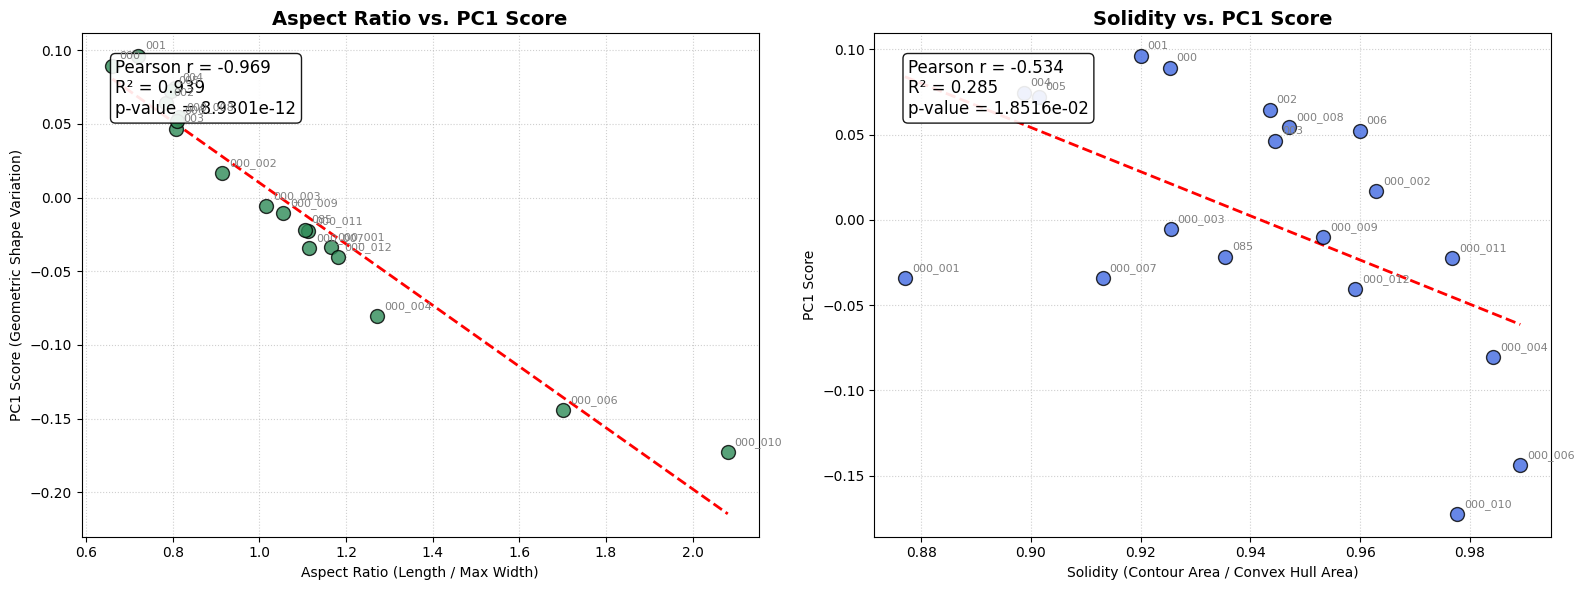

              🔬 形態學交叉驗證結論報告 (長寬比 vs Solidity)               
【1】傳統長寬比 (Aspect Ratio)：
     -> 顯著相關 (p = 8.9301e-12)，R² = 0.939

【2】輪廓實心度/凸包比 (Solidity)：
     -> 顯著相關 (p = 1.8516e-02)，R² = 0.285
     💡 結論：PC1 捕捉到的重要形狀變異，實質上反映了花瓣的「邊緣複雜度」。
        這可能代表某些物種的花瓣邊緣有明顯的波浪、缺刻，或者基部收縮較劇烈。


In [39]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 提取 DataFrame 中的數值進行迴歸分析
# ==========================================
aspect_ratios_array = df_metrics['Aspect_Ratio'].values
solidity_array = df_metrics['Solidity'].values
pc1_scores_array = df_metrics['PC1_Score'].values

# 計算 1: 長寬比 vs PC1
slope_ar, intercept_ar, r_ar, p_ar, _ = stats.linregress(aspect_ratios_array, pc1_scores_array)
r2_ar = r_ar ** 2

# 計算 2: Solidity vs PC1 🌟
slope_sol, intercept_sol, r_sol, p_sol, _ = stats.linregress(solidity_array, pc1_scores_array)
r2_sol = r_sol ** 2

# ==========================================
# 繪製相關性散佈圖 (1x2 雙圖並排)
# ==========================================
fig_corr, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左圖：Aspect Ratio vs PC1 ---
axes[0].scatter(aspect_ratios_array, pc1_scores_array, color='seagreen', s=100, alpha=0.8, edgecolors='k', zorder=3)
trendline_x_ar = np.linspace(min(aspect_ratios_array), max(aspect_ratios_array), 100)
axes[0].plot(trendline_x_ar, slope_ar * trendline_x_ar + intercept_ar, color='red', linestyle='--', linewidth=2, zorder=2)

axes[0].set_title("Aspect Ratio vs. PC1 Score", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Aspect Ratio (Length / Max Width)")
axes[0].set_ylabel("PC1 Score (Geometric Shape Variation)")
stats_text_ar = f"Pearson r = {r_ar:.3f}\nR² = {r2_ar:.3f}\np-value = {p_ar:.4e}"
axes[0].text(0.05, 0.95, stats_text_ar, transform=axes[0].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

for i, label in enumerate(df_metrics['Filename']):
    axes[0].annotate(label, (aspect_ratios_array[i], pc1_scores_array[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, color='gray')
axes[0].grid(True, linestyle=':', alpha=0.6, zorder=0)


# --- 右圖：Solidity vs PC1 🌟 ---
axes[1].scatter(solidity_array, pc1_scores_array, color='royalblue', s=100, alpha=0.8, edgecolors='k', zorder=3)
trendline_x_sol = np.linspace(min(solidity_array), max(solidity_array), 100)
axes[1].plot(trendline_x_sol, slope_sol * trendline_x_sol + intercept_sol, color='red', linestyle='--', linewidth=2, zorder=2)

axes[1].set_title("Solidity vs. PC1 Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Solidity (Contour Area / Convex Hull Area)")
axes[1].set_ylabel("PC1 Score")
stats_text_sol = f"Pearson r = {r_sol:.3f}\nR² = {r2_sol:.3f}\np-value = {p_sol:.4e}"
axes[1].text(0.05, 0.95, stats_text_sol, transform=axes[1].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

for i, label in enumerate(df_metrics['Filename']):
    axes[1].annotate(label, (solidity_array[i], pc1_scores_array[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, color='gray')
axes[1].grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()

# ==========================================
# 終端機列印科學結論
# ==========================================
print("="*70)
print(f"{'🔬 形態學交叉驗證結論報告 (長寬比 vs Solidity)':^60}")
print("="*70)

print("【1】傳統長寬比 (Aspect Ratio)：")
if p_ar < 0.05:
    print(f"     -> 顯著相關 (p = {p_ar:.4e})，R² = {r2_ar:.3f}")
else:
    print(f"     -> 無顯著相關 (p = {p_ar:.4e})")

print("\n【2】輪廓實心度/凸包比 (Solidity)：")
if p_sol < 0.05:
    print(f"     -> 顯著相關 (p = {p_sol:.4e})，R² = {r2_sol:.3f}")
    print("     💡 結論：PC1 捕捉到的重要形狀變異，實質上反映了花瓣的「邊緣複雜度」。")
    print("        這可能代表某些物種的花瓣邊緣有明顯的波浪、缺刻，或者基部收縮較劇烈。")
else:
    print(f"     -> 無顯著相關 (p = {p_sol:.4e})")
    print("     💡 結論：PC1 代表的既不是單純的長寬比，也不是實心度。這群花瓣的形變")
    print("        可能牽涉到更非線性的特徵 (如花瓣重心的偏移、左右不對稱性)。")
print("="*70)

[*] 正在進行花瓣顏色量化 (CIELAB 色彩空間 & K-Means 提取主要顏色)...


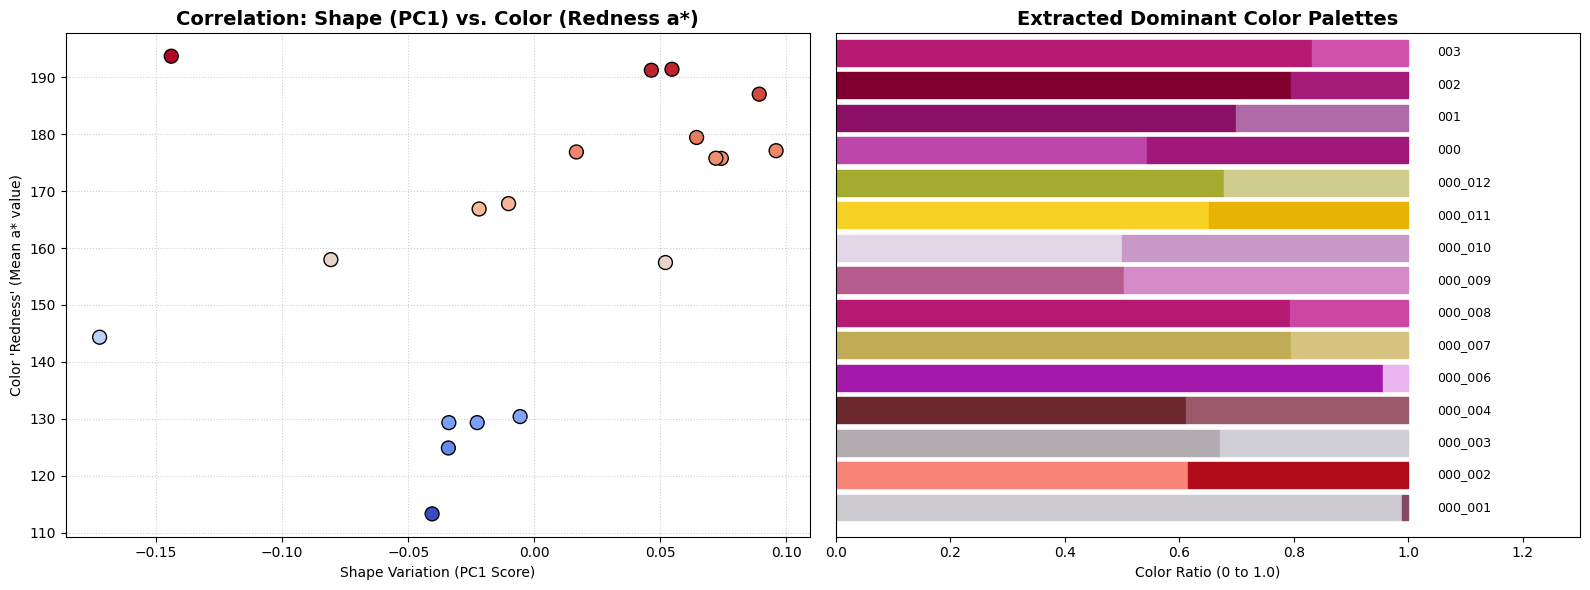

,Filename,PC1_Score,Mean_a,Dom1_Ratio,Dom2_Ratio
0,000_001,-0.033874,129.328364,0.9894,0.0106
1,000_002,0.016721,176.880576,0.6146,0.3854
2,000_003,-0.005596,130.398242,0.6710,0.3290
3,000_004,-0.080682,157.967982,0.6124,0.3876
4,000_006,-0.143986,193.701329,0.9566,0.0434


In [40]:
# ==========================================
# 7. 顏色量化 (Color Quantification) - CIELAB & K-Means
# ==========================================
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

print("[*] 正在進行花瓣顏色量化 (CIELAB 色彩空間 & K-Means 提取主要顏色)...")

color_metrics = []

# 設定 K-Means 要抓取幾個主要顏色 (這裡設 2，代表底色與斑紋/漸層色)
num_dominant_colors = 2

for idx, label in enumerate(valid_filenames):
    base_name = label.split('_p')[0]
    img_path = os.path.join(image_dir, f"{base_name}_image.png")
    mask_path = os.path.join(mask_dir, f"{base_name}_mask.png")
    
    img_bgr = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if img_bgr is None or mask is None:
        continue
        
    # 提取花瓣 (Class 7) 的 Mask
    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    
    # 轉換色彩空間
    # 1. 轉為 RGB (用於視覺化呈現)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # 2. 轉為 LAB (用於科學計算 L*a*b*)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    
    # 只取出 Mask 內的有效像素
    pixels_rgb = img_rgb[mask_c7 == 255]
    pixels_lab = img_lab[mask_c7 == 255]
    
    if len(pixels_lab) == 0:
        continue

    # 計算整片花瓣的「平均」LAB 數值
    mean_lab = np.mean(pixels_lab, axis=0)
    
    # --------------------------------------------------
    # 使用 K-Means 提取最具代表性的主要顏色 (Dominant Colors)
    # --------------------------------------------------
    # 為了加速運算，隨機抽樣 5000 個像素點來做分群即可
    if len(pixels_lab) > 5000:
        sample_indices = np.random.choice(len(pixels_lab), 5000, replace=False)
        sample_pixels_lab = pixels_lab[sample_indices]
        sample_pixels_rgb = pixels_rgb[sample_indices]
    else:
        sample_pixels_lab = pixels_lab
        sample_pixels_rgb = pixels_rgb
        
    # 使用 RGB 空間進行 K-Means 分群 (抓出來的顏色方便畫圖顯示)
    kmeans = KMeans(n_clusters=num_dominant_colors, random_state=42, n_init=10)
    kmeans.fit(sample_pixels_rgb)
    
    # 計算每種顏色佔比，並依照佔比大小排序
    labels_count = np.bincount(kmeans.labels_)
    percentages = labels_count / len(sample_pixels_rgb)
    sorted_indices = np.argsort(percentages)[::-1] # 佔比高的排前面
    
    dominant_color_1 = kmeans.cluster_centers_[sorted_indices[0]] # 最主要的底色
    ratio_1 = percentages[sorted_indices[0]]
    
    dominant_color_2 = kmeans.cluster_centers_[sorted_indices[1]] # 第二大顏色 (斑點或漸層)
    ratio_2 = percentages[sorted_indices[1]]
    
    color_metrics.append({
        "Filename": label,
        "PC1_Score": pcs[idx, 0],
        "PC2_Score": pcs[idx, 1],
        "Mean_L": mean_lab[0], # 亮度 (0~255 範圍)
        "Mean_a": mean_lab[1], # 綠-紅 軸 (越小越綠，越大越紅)
        "Mean_b": mean_lab[2], # 藍-黃 軸 (越小越藍，越大越黃)
        "Dom1_R": dominant_color_1[0],
        "Dom1_G": dominant_color_1[1],
        "Dom1_B": dominant_color_1[2],
        "Dom1_Ratio": ratio_1,
        "Dom2_R": dominant_color_2[0],
        "Dom2_G": dominant_color_2[1],
        "Dom2_B": dominant_color_2[2],
        "Dom2_Ratio": ratio_2
    })

# 將顏色數據整理成 DataFrame
df_color = pd.DataFrame(color_metrics)

# ==========================================
# 視覺化：將「形狀 (PC1)」與「平均顏色 (a* 軸, 偏紅程度)」進行相關性分析
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左圖：形狀 (PC1) vs 顏色偏紅程度 (Mean a*) ---
axes[0].scatter(df_color['PC1_Score'], df_color['Mean_a'], 
                c=df_color['Mean_a'], cmap='coolwarm', s=100, edgecolors='k')
axes[0].set_title("Correlation: Shape (PC1) vs. Color (Redness a*)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Shape Variation (PC1 Score)")
axes[0].set_ylabel("Color 'Redness' (Mean a* value)")
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- 右圖：色盤展示 (展示每朵花抓出的 Top 2 顏色) ---
# 為了版面美觀，我們最多展示前 15 朵花的色塊
display_limit = min(15, len(df_color))
y_positions = np.arange(display_limit)

for i in range(display_limit):
    # 畫第一主要色塊
    c1 = [df_color.loc[i, 'Dom1_R']/255, df_color.loc[i, 'Dom1_G']/255, df_color.loc[i, 'Dom1_B']/255]
    axes[1].add_patch(plt.Rectangle((0, i), df_color.loc[i, 'Dom1_Ratio'], 0.8, color=c1))
    
    # 畫第二主要色塊
    c2 = [df_color.loc[i, 'Dom2_R']/255, df_color.loc[i, 'Dom2_G']/255, df_color.loc[i, 'Dom2_B']/255]
    axes[1].add_patch(plt.Rectangle((df_color.loc[i, 'Dom1_Ratio'], i), df_color.loc[i, 'Dom2_Ratio'], 0.8, color=c2))
    
    axes[1].text(1.05, i+0.4, f"{df_color.loc[i, 'Filename']}", va='center', fontsize=9)

axes[1].set_xlim(0, 1.3)
axes[1].set_ylim(-0.5, display_limit)
axes[1].set_yticks([])
axes[1].set_title("Extracted Dominant Color Palettes", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Color Ratio (0 to 1.0)")

plt.tight_layout()
plt.show()

# 顯示前 5 筆資料供核對
display(df_color[['Filename', 'PC1_Score', 'Mean_a', 'Dom1_Ratio', 'Dom2_Ratio']].head())